<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Mall_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import os
import glob
import time
import warnings
import shutil

print("Libraries imported successfully.")


import warnings
warnings.filterwarnings("ignore")


Libraries imported successfully.


In [ ]:
df=pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.shape

(200, 5)

In [ ]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
135,136,Female,29,73,88
90,91,Female,68,59,55
84,85,Female,21,54,57
166,167,Male,42,86,20
89,90,Female,50,58,46


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.drop(columns=['CustomerID'],inplace=True)

In [ ]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


EDA

Univariate Analysis

In [ ]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [ ]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

features = [
    col for col in numeric_features
    if "id" not in col.lower()
]

X = df[features].copy()

print("Features used:")
print(features)

display(X.head())

Features used:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
numeric_features

['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

In [ ]:
categorical_features

['Gender']

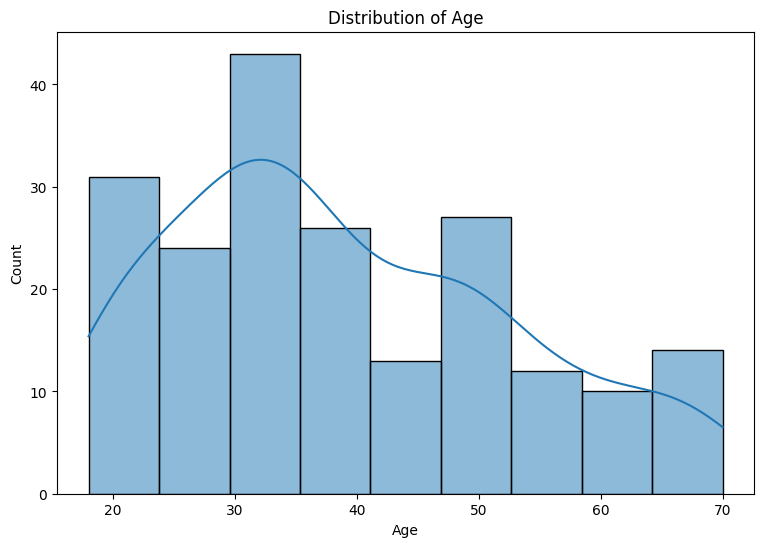

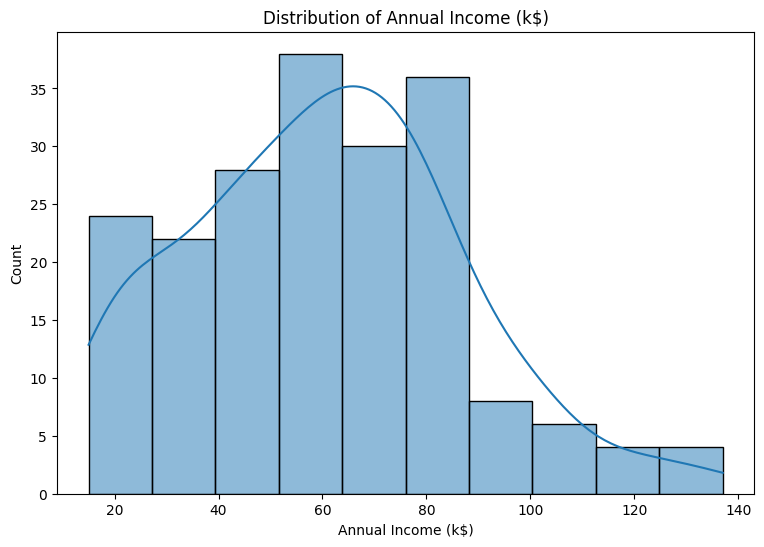

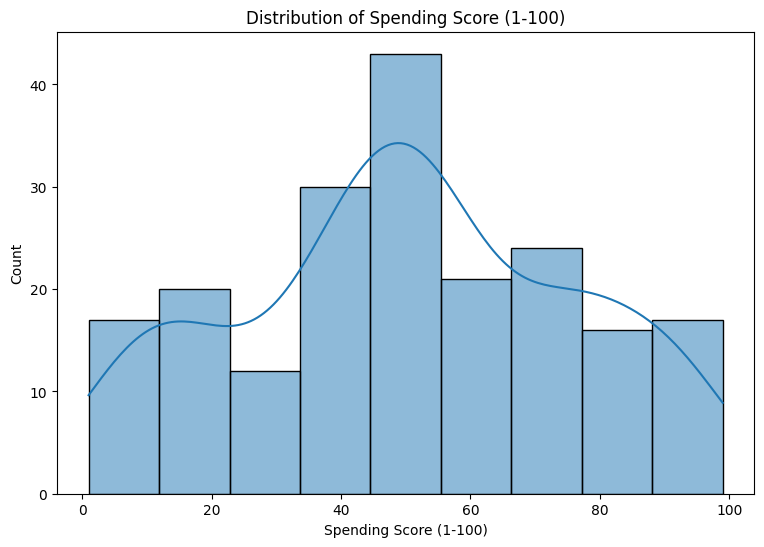

In [ ]:
for column in numeric_features:
  plt.figure(figsize=(9,6))
  sns.histplot(df[column],kde=True)
  plt.xlabel(column)
  plt.ylabel("Count")
  plt.title(f"Distribution of {column}")
  plt.show()


**preprocessing**

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled,columns=X.columns)
display(X_scaled.head())


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


**Modeling**

In [ ]:
# find the best k for k-means
k_rows = []

for k in range(2, 9):
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    k_rows.append({
        "K": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Inertia": km.inertia_
    })

k_table = pd.DataFrame(k_rows)
display(k_table.round(4))

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
0,2,0.3355,1.2607,107.0956,389.3862
1,3,0.3578,1.0503,101.6949,295.2122
2,4,0.4040,0.9308,125.6764,205.2251
3,5,0.4166,0.8746,125.1009,168.2476
4,6,0.4274,0.8277,135.1022,133.8683
5,7,0.4172,0.7935,132.7743,117.0116
6,8,0.4087,0.8893,131.0744,103.8286


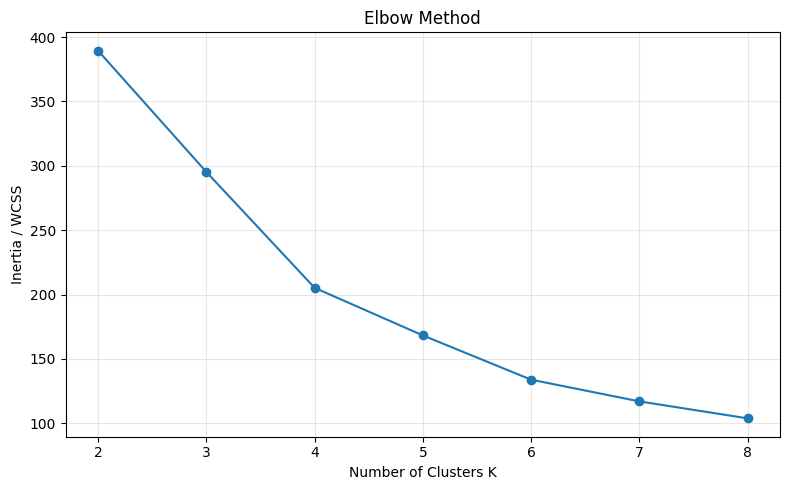

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_table["K"], k_table["Inertia"], marker="o")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
rank_table = k_table.copy()

rank_table["R_Sil"] = rank_table["Silhouette"].rank(ascending=False)
rank_table["R_DBI"] = rank_table["Davies_Bouldin"].rank(ascending=True)
rank_table["R_CH"] = rank_table["Calinski_Harabasz"].rank(ascending=False)

rank_table["Combined_Rank"] = (
    rank_table["R_Sil"] +
    rank_table["R_DBI"] +
    rank_table["R_CH"]
)

rank_table = rank_table.sort_values("Combined_Rank")

BEST_K = int(rank_table.iloc[0]["K"])

display(rank_table.round(3))
print("Selected K =", BEST_K)

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia,R_Sil,R_DBI,R_CH,Combined_Rank
4,6,0.427,0.828,135.102,133.868,1.0,2.0,1.0,4.0
5,7,0.417,0.793,132.774,117.012,2.0,1.0,2.0,5.0
3,5,0.417,0.875,125.101,168.248,3.0,3.0,5.0,11.0
6,8,0.409,0.889,131.074,103.829,4.0,4.0,3.0,11.0
2,4,0.404,0.931,125.676,205.225,5.0,5.0,4.0,14.0
1,3,0.358,1.050,101.695,295.212,6.0,6.0,7.0,19.0
0,2,0.335,1.261,107.096,389.386,7.0,7.0,6.0,20.0


Selected K = 6


kmeans

In [ ]:
start = time.perf_counter()

basic_kmeans = KMeans(
    n_clusters=BEST_K,
    init="random",
    n_init=1,
    random_state=42
)

labels_kmeans = basic_kmeans.fit_predict(X_scaled)
time_kmeans= time.perf_counter() - start

print("K-Means++ completed.")

print("Basic K-Means completed.")

K-Means++ completed.
Basic K-Means completed.


kmeans ++

In [ ]:
start = time.perf_counter()

kmeans_pp = KMeans(
    n_clusters=BEST_K,
    init="k-means++",
    n_init=50,
    random_state=42
)

labels_kmeans_pp = kmeans_pp.fit_predict(X_scaled)
time_kmeans_pp = time.perf_counter() - start

print("K-Means++ completed.")

K-Means++ completed.


mini batch k-means

In [ ]:
start = time.perf_counter()

mini_kmeans = MiniBatchKMeans(
    n_clusters=BEST_K,
    n_init=20,
    random_state=42
)

labels_mini = mini_kmeans.fit_predict(X_scaled)
time_mini = time.perf_counter() - start

print("MiniBatch K-Means completed.")




MiniBatch K-Means completed.


Run Agglomerative Clustering

In [ ]:
start = time.perf_counter()

agg = AgglomerativeClustering(
    n_clusters=BEST_K
)

labels_agg = agg.fit_predict(X_scaled)
time_agg = time.perf_counter() - start

print("Agglomerative clustering completed.")





Agglomerative clustering completed.


Gaussian Mixture Model

In [ ]:
start = time.perf_counter()

gmm = GaussianMixture(
    n_components=BEST_K,
    n_init=10,
    random_state=42
)

labels_gmm = gmm.fit_predict(X_scaled)
time_gmm = time.perf_counter() - start

print("Gaussian Mixture completed.")



Gaussian Mixture completed.


DBSCAN

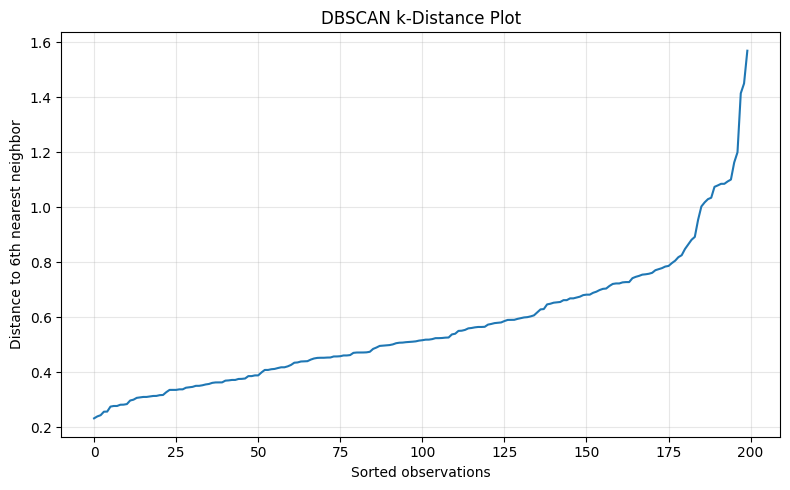

Initial min_samples = 6


In [ ]:
# K DISTANCE PLOT FOR DBSCAN
MIN_SAMPLES = max(4, 2 * X_scaled.shape[1])
nn = NearestNeighbors(
    n_neighbors=MIN_SAMPLES
)
nn.fit(X_scaled)

distances, indices = nn.kneighbors(X_scaled)

k_distances = np.sort(
    distances[:, -1]
)
plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor")
plt.title("DBSCAN k-Distance Plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Initial min_samples =", MIN_SAMPLES)

In [ ]:
eps_values = np.unique(
    np.quantile(
        k_distances,
        np.linspace(0.70, 0.99, 20)
    )
)

dbscan_search = []

for eps in eps_values:

    model = DBSCAN(
        eps=float(eps),
        min_samples=MIN_SAMPLES
    )

    labels = model.fit_predict(X_scaled)

    mask = labels != -1
    clusters = np.unique(labels[mask])

    if len(clusters) >= 2 and mask.sum() > len(clusters):

        dbscan_search.append({
            "EPS": eps,
            "Clusters": len(clusters),
            "Noise": int(np.sum(labels == -1)),
            "Silhouette": silhouette_score(X_scaled[mask], labels[mask]),
            "Davies_Bouldin": davies_bouldin_score(X_scaled[mask], labels[mask]),
            "Calinski_Harabasz": calinski_harabasz_score(X_scaled[mask], labels[mask])
        })

dbscan_table = pd.DataFrame(dbscan_search)

if len(dbscan_table) == 0:
    raise RuntimeError("No valid DBSCAN configuration found.")

display(
    dbscan_table
    .sort_values("Silhouette", ascending=False)
    .head(10)
    .round(4)
)


,EPS,Clusters,Noise,Silhouette,Davies_Bouldin,Calinski_Harabasz
2,0.6682,2,23,0.2675,1.0395,54.6212
1,0.6573,3,24,0.0890,1.3381,28.6862
0,0.6498,3,26,0.0836,1.3365,26.6671


In [ ]:
db_rank = dbscan_table.copy()

db_rank["R_Sil"] = db_rank["Silhouette"].rank(ascending=False)
db_rank["R_DBI"] = db_rank["Davies_Bouldin"].rank(ascending=True)
db_rank["R_CH"] = db_rank["Calinski_Harabasz"].rank(ascending=False)
db_rank["R_Noise"] = db_rank["Noise"].rank(ascending=True)

db_rank["Combined_Rank"] = (
    db_rank["R_Sil"] +
    db_rank["R_DBI"] +
    db_rank["R_CH"] +
    0.5 * db_rank["R_Noise"]
)

db_rank = db_rank.sort_values("Combined_Rank")

BEST_EPS = float(db_rank.iloc[0]["EPS"])

display(db_rank.head(10).round(4))

print("Selected DBSCAN eps =", BEST_EPS)
print("Selected min_samples =", MIN_SAMPLES)

,EPS,Clusters,Noise,Silhouette,Davies_Bouldin,Calinski_Harabasz,R_Sil,R_DBI,R_CH,R_Noise,Combined_Rank
2,0.6682,2,23,0.2675,1.0395,54.6212,1.0,1.0,1.0,1.0,3.5
1,0.6573,3,24,0.0890,1.3381,28.6862,2.0,3.0,2.0,2.0,8.0
0,0.6498,3,26,0.0836,1.3365,26.6671,3.0,2.0,3.0,3.0,9.5


Selected DBSCAN eps = 0.6682319227087148
Selected min_samples = 6


In [ ]:
start = time.perf_counter()

dbscan = DBSCAN(
    eps=BEST_EPS,
    min_samples=MIN_SAMPLES
)

labels_dbscan = dbscan.fit_predict(X_scaled)
time_dbscan = time.perf_counter() - start

print("DBSCAN completed.")
print("Noise points:", int(np.sum(labels_dbscan == -1)))

DBSCAN completed.
Noise points: 23


In [ ]:
def evaluate_clustering(name, X_data, labels, runtime):

    labels = np.asarray(labels)

    noise_points = int(np.sum(labels == -1))

    if noise_points > 0:
        mask = labels != -1
        X_eval = np.asarray(X_data)[mask]
        labels_eval = labels[mask]
    else:
        X_eval = np.asarray(X_data)
        labels_eval = labels

    unique_clusters = np.unique(labels_eval)

    if len(unique_clusters) < 2:
        return {
            "Algorithm": name,
            "Clusters": len(unique_clusters),
            "Noise_Points": noise_points,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "Runtime_seconds": runtime
        }

    return {
        "Algorithm": name,
        "Clusters": len(unique_clusters),
        "Noise_Points": noise_points,
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Davies_Bouldin": davies_bouldin_score(X_eval, labels_eval),
        "Calinski_Harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "Runtime_seconds": runtime
    }

print("Evaluation function ready.")

Evaluation function ready.


In [ ]:
results = [
    evaluate_clustering("Basic K-Means", X_scaled, labels_kmeans, time_kmeans),
    evaluate_clustering("K-Means++", X_scaled, labels_kmeans_pp, time_kmeans_pp),
    evaluate_clustering("MiniBatch K-Means", X_scaled, labels_mini, time_mini),
    evaluate_clustering("Agglomerative", X_scaled, labels_agg, time_agg),
    evaluate_clustering("Gaussian Mixture", X_scaled, labels_gmm, time_gmm),
    evaluate_clustering("DBSCAN", X_scaled, labels_dbscan, time_dbscan)
]

comparison_df = pd.DataFrame(results)

display(comparison_df.round(4))

,Algorithm,Clusters,Noise_Points,Silhouette,Davies_Bouldin,Calinski_Harabasz,Runtime_seconds
0,Basic K-Means,6,0,0.3725,0.9974,111.1227,0.0063
1,K-Means++,6,0,0.4274,0.8277,135.1022,0.0061
2,MiniBatch K-Means,6,0,0.4284,0.8254,135.1021,0.0339
3,Agglomerative,6,0,0.4201,0.8521,127.9865,0.0037
4,Gaussian Mixture,6,0,0.3767,0.8713,107.5909,0.2090
5,DBSCAN,2,23,0.2675,1.0395,54.6212,0.0048


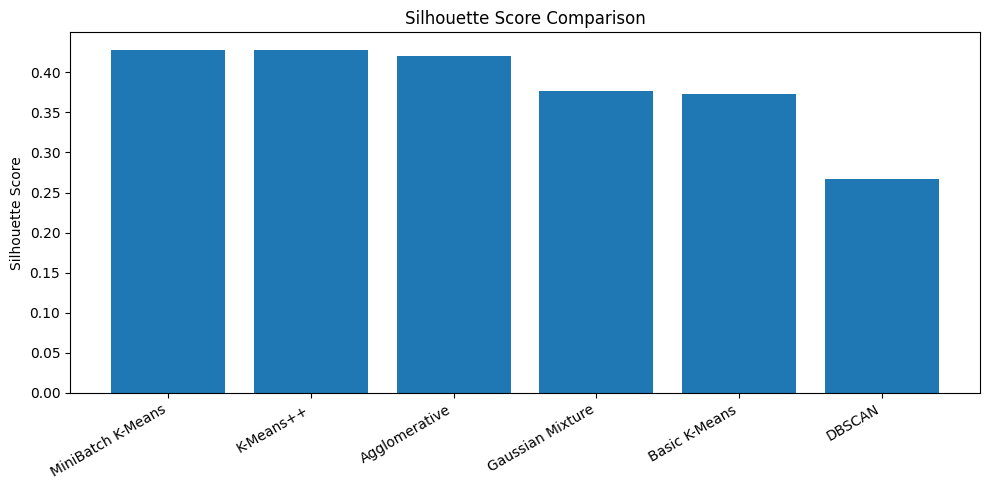

In [ ]:
plot_df = comparison_df.sort_values("Silhouette", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(plot_df["Algorithm"], plot_df["Silhouette"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison")
plt.tight_layout()
plt.show()


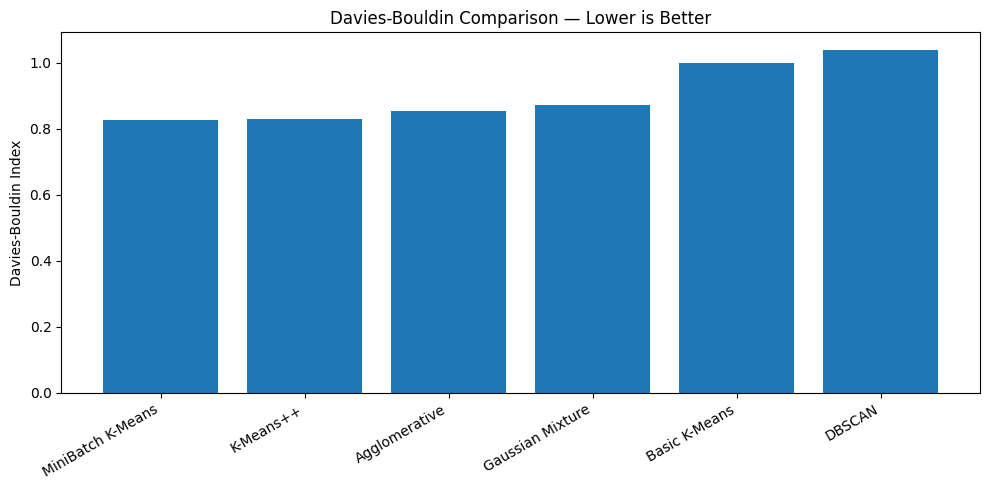

In [ ]:
plot_df = comparison_df.sort_values("Davies_Bouldin")

plt.figure(figsize=(10,5))
plt.bar(plot_df["Algorithm"], plot_df["Davies_Bouldin"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Comparison — Lower is Better")
plt.tight_layout()
plt.show()

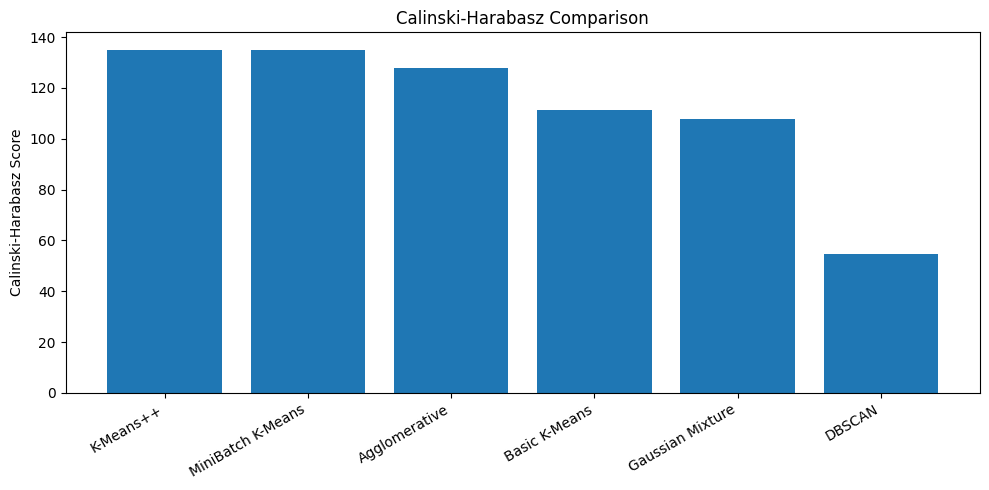

In [ ]:
plot_df = comparison_df.sort_values("Calinski_Harabasz", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(plot_df["Algorithm"], plot_df["Calinski_Harabasz"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Comparison")
plt.tight_layout()
plt.show()

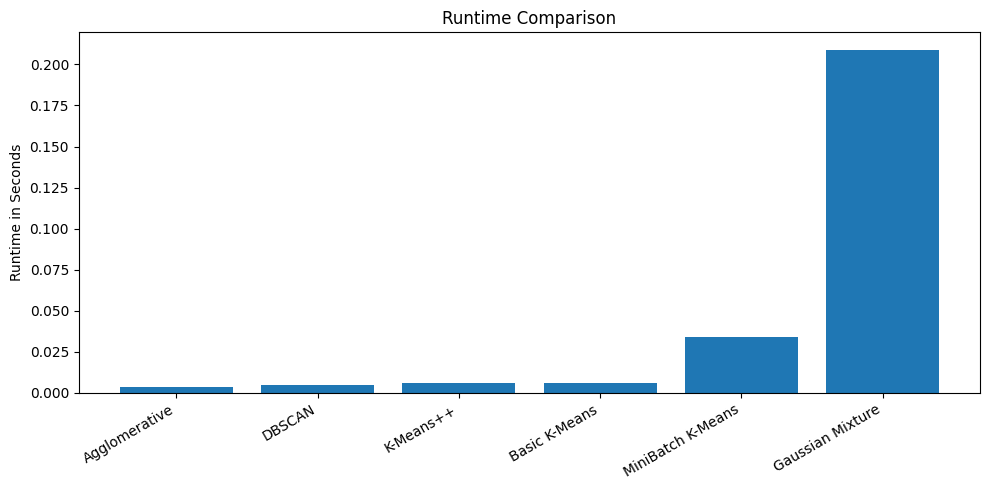

In [ ]:
plot_df = comparison_df.sort_values("Runtime_seconds")

plt.figure(figsize=(10,5))
plt.bar(plot_df["Algorithm"], plot_df["Runtime_seconds"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Runtime in Seconds")
plt.title("Runtime Comparison")
plt.tight_layout()
plt.show()

In [ ]:
ranking = comparison_df.copy()

ranking["R_Sil"] = ranking["Silhouette"].rank(ascending=False)
ranking["R_DBI"] = ranking["Davies_Bouldin"].rank(ascending=True)
ranking["R_CH"] = ranking["Calinski_Harabasz"].rank(ascending=False)

ranking["Overall_Rank"] = (
    ranking["R_Sil"] +
    ranking["R_DBI"] +
    ranking["R_CH"]
)

ranking = ranking.sort_values("Overall_Rank")

display(ranking.round(4))

print(
    "Best overall algorithm by combined internal metrics:",
    ranking.iloc[0]["Algorithm"]
)

,Algorithm,Clusters,Noise_Points,Silhouette,Davies_Bouldin,Calinski_Harabasz,Runtime_seconds,R_Sil,R_DBI,R_CH,Overall_Rank
2,MiniBatch K-Means,6,0,0.4284,0.8254,135.1021,0.0339,1.0,1.0,2.0,4.0
1,K-Means++,6,0,0.4274,0.8277,135.1022,0.0061,2.0,2.0,1.0,5.0
3,Agglomerative,6,0,0.4201,0.8521,127.9865,0.0037,3.0,3.0,3.0,9.0
4,Gaussian Mixture,6,0,0.3767,0.8713,107.5909,0.2090,4.0,4.0,5.0,13.0
0,Basic K-Means,6,0,0.3725,0.9974,111.1227,0.0063,5.0,5.0,4.0,14.0
5,DBSCAN,2,23,0.2675,1.0395,54.6212,0.0048,6.0,6.0,6.0,18.0


Best overall algorithm by combined internal metrics: MiniBatch K-Means


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Variance represented by first two PCs:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Variance represented by first two PCs: 77.57 %


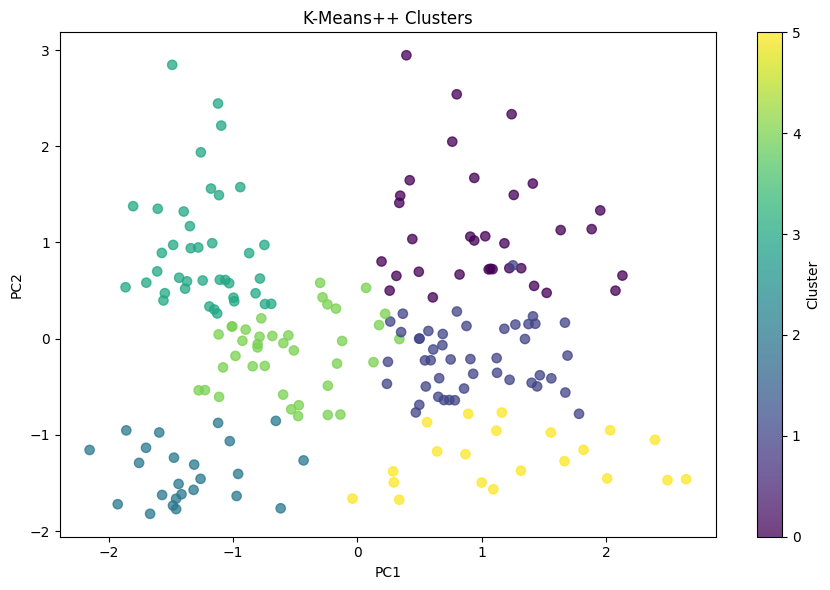

In [ ]:
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_kmeans_pp,
    s=45,
    alpha=0.75
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means++ Clusters")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

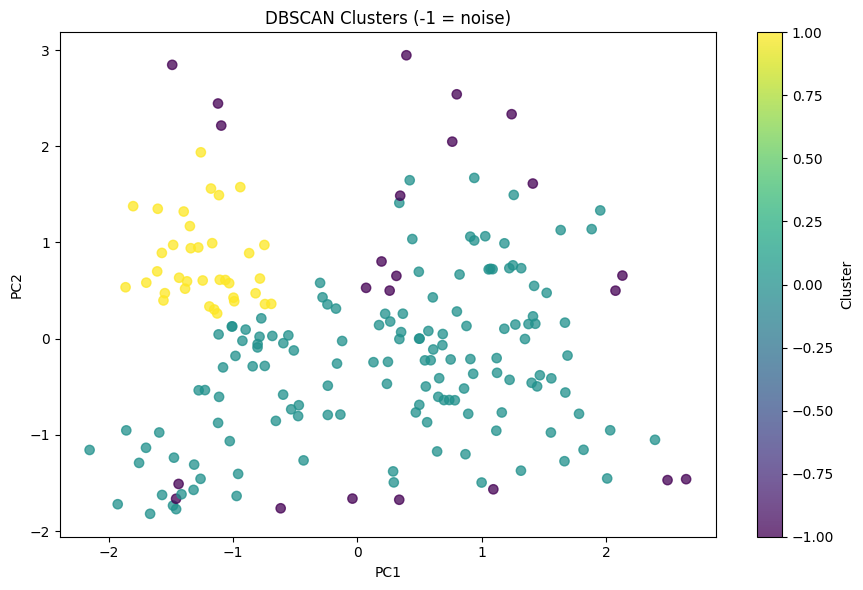

In [ ]:
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_dbscan,
    s=45,
    alpha=0.75
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (-1 = noise)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

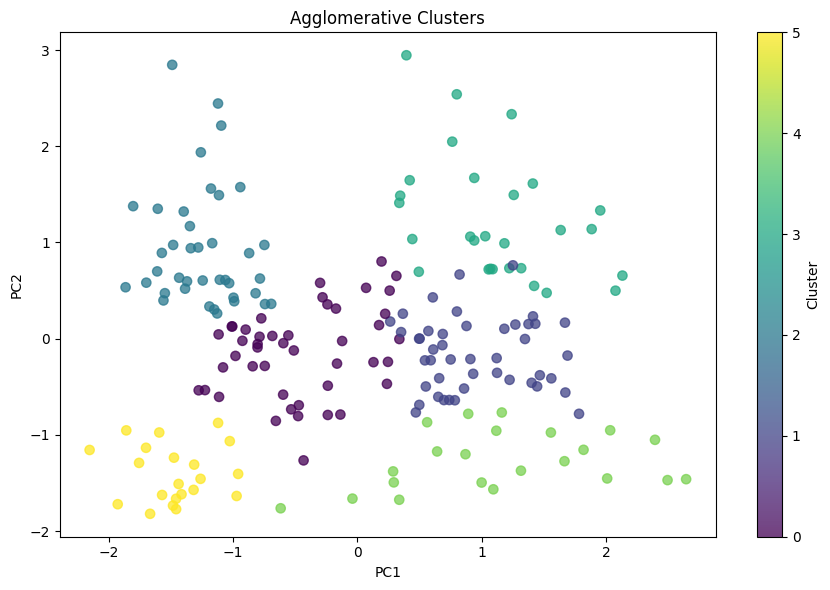

In [ ]:
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_agg,
    s=45,
    alpha=0.75
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clusters")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [ ]:
best_sil = comparison_df.sort_values("Silhouette", ascending=False).iloc[0]
best_dbi = comparison_df.sort_values("Davies_Bouldin").iloc[0]
best_ch = comparison_df.sort_values("Calinski_Harabasz", ascending=False).iloc[0]

print("BEST BY SILHOUETTE:")
print(best_sil["Algorithm"], round(best_sil["Silhouette"], 4))

print("\nBEST BY DAVIES-BOULDIN:")
print(best_dbi["Algorithm"], round(best_dbi["Davies_Bouldin"], 4))

print("\nBEST BY CALINSKI-HARABASZ:")
print(best_ch["Algorithm"], round(best_ch["Calinski_Harabasz"], 4))

print("\nDBSCAN NOISE POINTS:")
print(int(np.sum(labels_dbscan == -1)))

BEST BY SILHOUETTE:
MiniBatch K-Means 0.4284

BEST BY DAVIES-BOULDIN:
MiniBatch K-Means 0.8254

BEST BY CALINSKI-HARABASZ:
K-Means++ 135.1022

DBSCAN NOISE POINTS:
23
